**Heart Disease Indicator:**

**Done By**

Amro Adel Abdulrahman Rashed

Mouawia Aldaliee

Bimo Kuncoro Yakti Prasetijo

Hussein Rashed Abdulwareth Al-manifi

Mursalin Bashar




---



Importing What's needed

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam
import matplotlib.pyplot as plt # Visualization library
import seaborn as sns # Visualization library
from sklearn import metrics
from sklearn.metrics import roc_curve, accuracy_score, RocCurveDisplay
from sklearn.model_selection import cross_val_score, StratifiedKFold




---



**Reading The Data Set**

In [ ]:
data = pd.read_csv("/content/heart.csv")
print(data.shape)
# info about the data set
print(data.info())

(918, 12)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    object 
 2   ChestPainType   918 non-null    object 
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    object 
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    object 
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    object 
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), object(5)
memory usage: 86.2+ KB
None


In [ ]:
# print the first 5 rows of the data set
data.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


Preprocessing

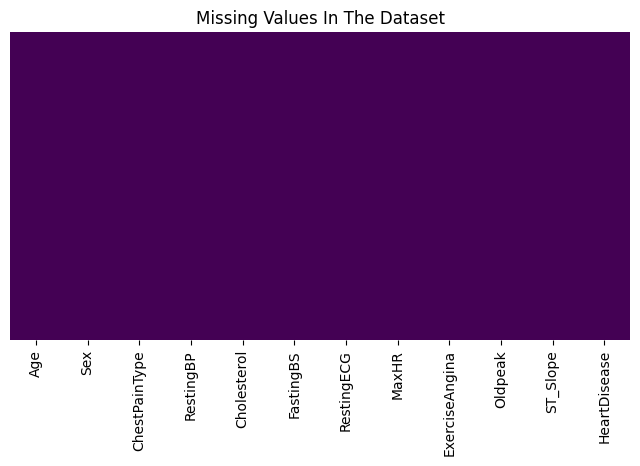



Age               0
Sex               0
ChestPainType     0
RestingBP         0
Cholesterol       0
FastingBS         0
RestingECG        0
MaxHR             0
ExerciseAngina    0
Oldpeak           0
ST_Slope          0
HeartDisease      0
dtype: int64


In [ ]:
# check if the Data set has any missing rows.
plt.figure(figsize=(8,4))
sns.heatmap(data.isnull(),cbar=False,cmap='viridis',yticklabels=False)
plt.title('Missing Values In The Dataset')
plt.show()

print("\n")
# check for null values
print(data.isnull().sum())

<Axes: xlabel='HeartDisease', ylabel='count'>

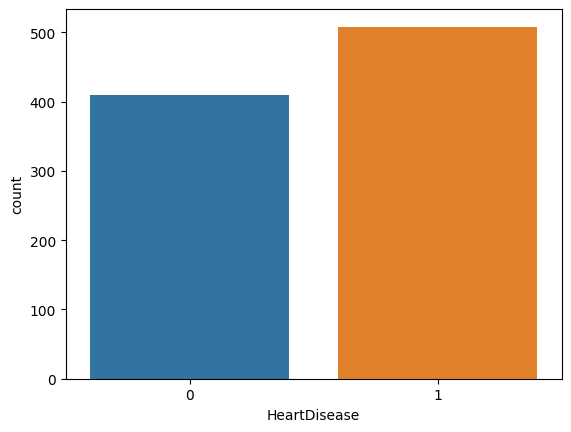

In [ ]:
# Check Data Points for each Class
sns.countplot(x='HeartDisease', data=data)

In [ ]:
# Convert categorical variables to numerical labels
label_encoder = LabelEncoder()
data['Sex'] = label_encoder.fit_transform(data['Sex'])
data['ChestPainType'] = label_encoder.fit_transform(data['ChestPainType'])
data['FastingBS'] = label_encoder.fit_transform(data['FastingBS'])
data['RestingECG'] = label_encoder.fit_transform(data['RestingECG'])
data['ExerciseAngina'] = label_encoder.fit_transform(data['ExerciseAngina'])
data['ST_Slope'] = label_encoder.fit_transform(data['ST_Slope'])

# New Section

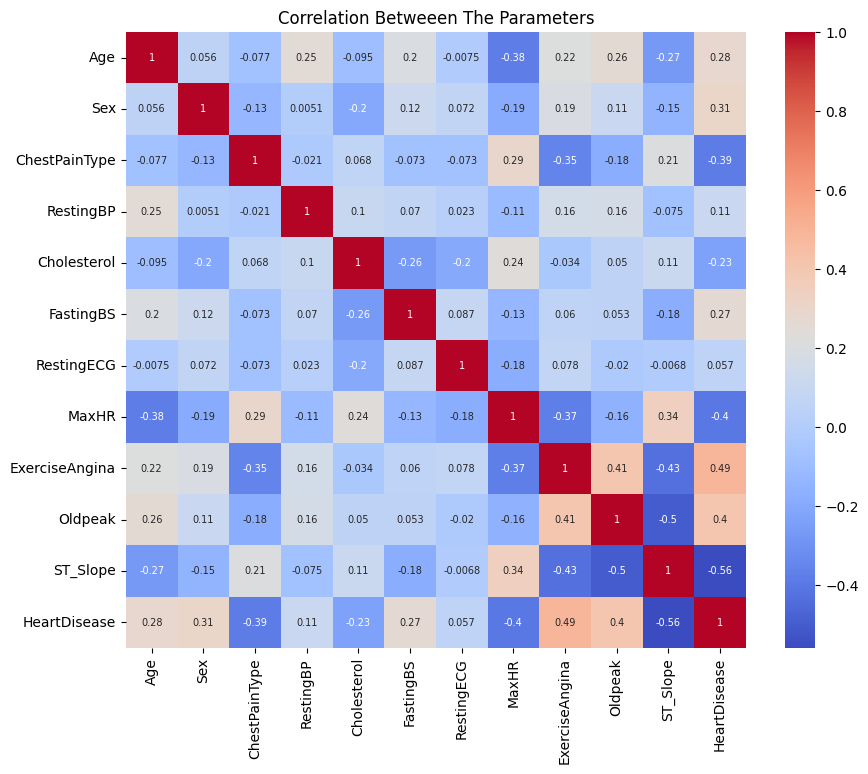

In [ ]:
# See The Corrlation Between each Feature
corr = data.corr()
plt.figure(figsize= (10,8))
plt.title('Correlation Betweeen The Parameters')
sns.heatmap(corr,
            xticklabels=corr.columns.values,
            yticklabels=corr.columns.values,
            cmap="coolwarm",
            annot=True,annot_kws={"fontsize":7})
plt.show()



---



**Relation Between each Feature and HeartDisease indication:**

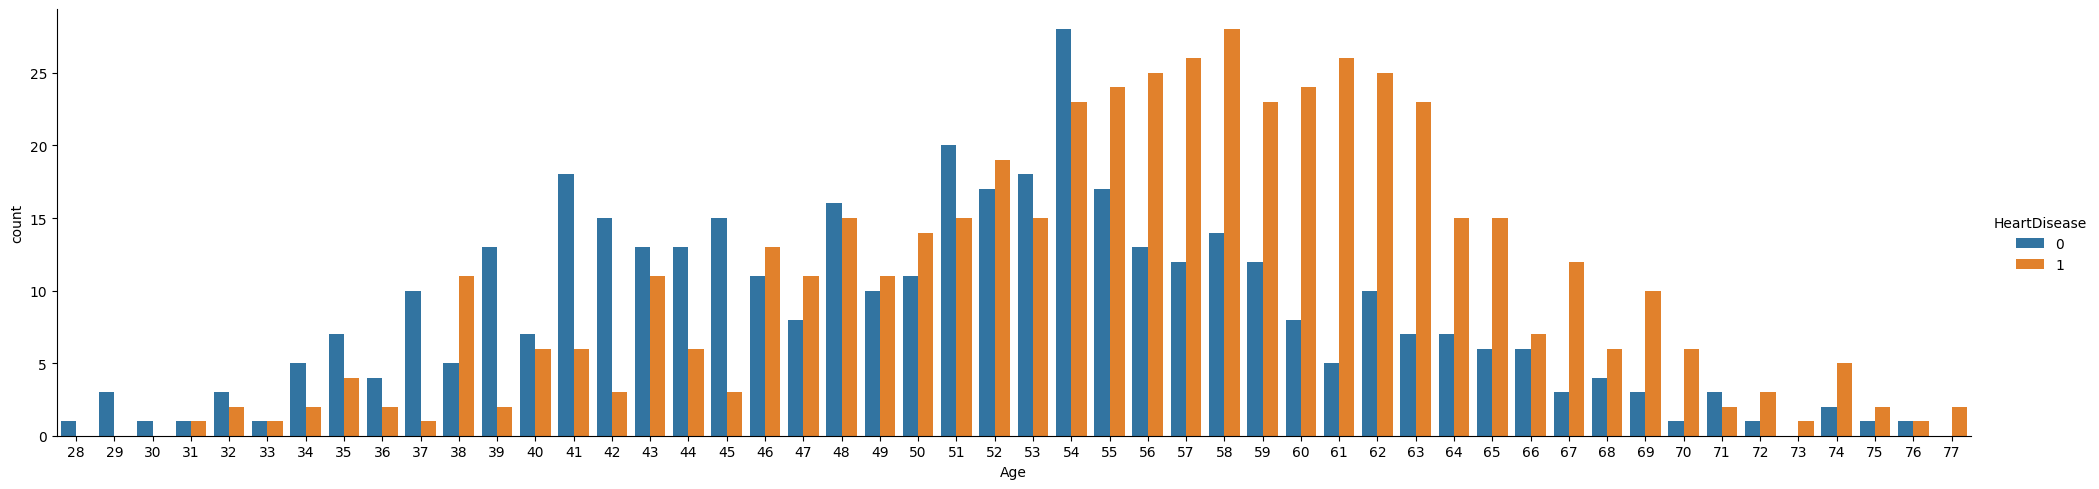

In [ ]:
# The Relation between Age and HeartDisease
age = sns.catplot(x="Age", hue="HeartDisease",data=data, kind = "count", aspect = 4)
plt.show()

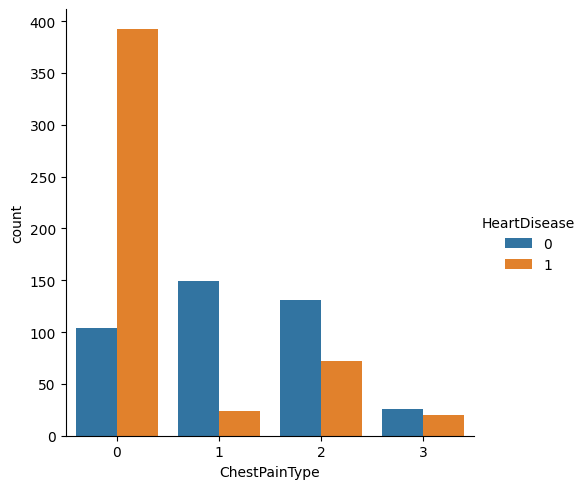

In [ ]:
# The Relation between ChestPainType and HeartDisease
ChestPainType = sns.catplot(x="ChestPainType", hue="HeartDisease",data=data, kind = "count")
plt.show()

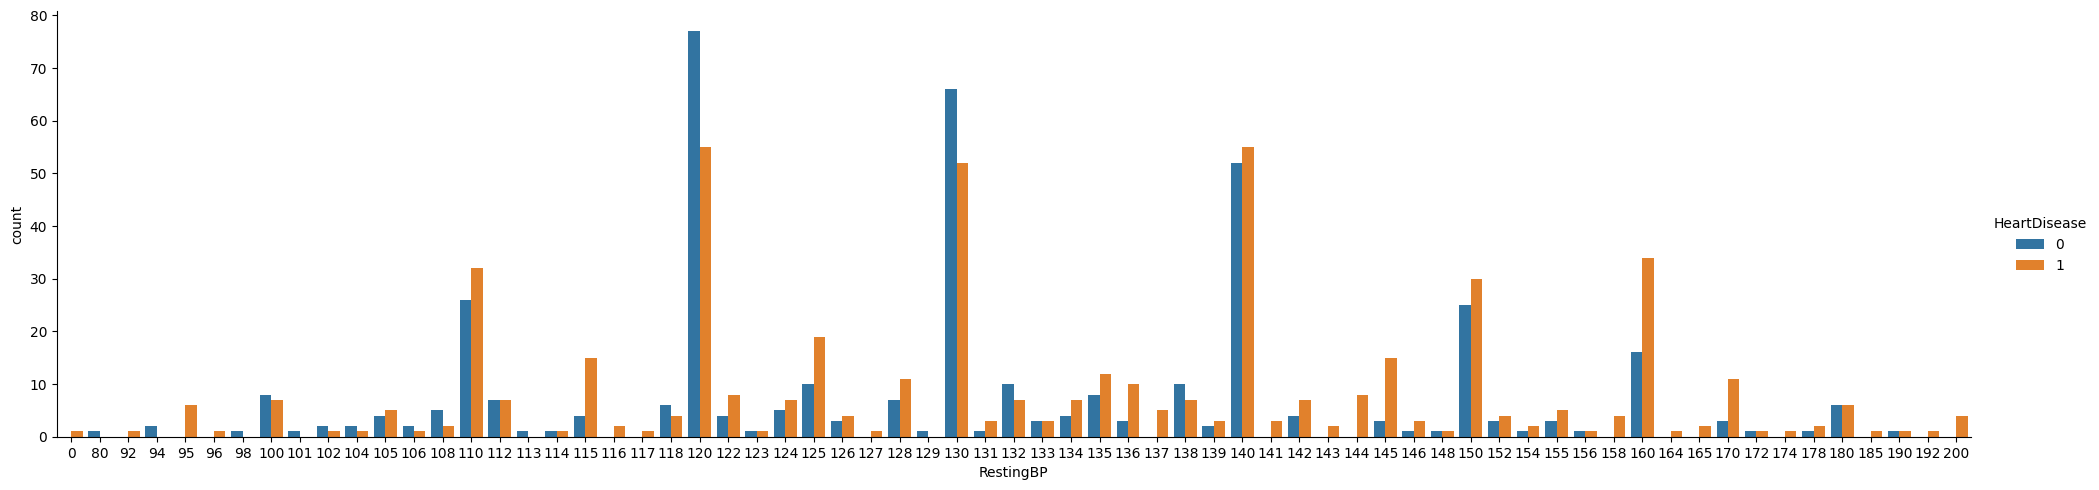

In [ ]:
# The Relation between RestingBP and HeartDisease
RestingBP = sns.catplot(x="RestingBP", hue="HeartDisease",data=data, kind = "count" , aspect = 4)
plt.show()

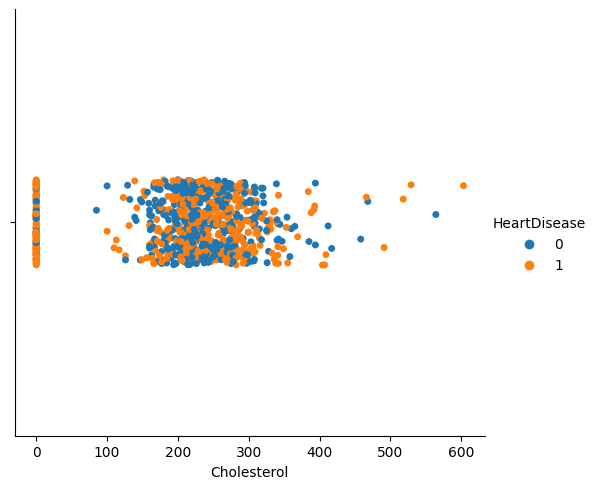

In [ ]:
# The Relation between Cholesterol and  HeartDisease
# we didn't do count here since the Cholesterol level for the patients varies.
Cholesterol = sns.catplot(x="Cholesterol", hue="HeartDisease",data=data)
plt.show()

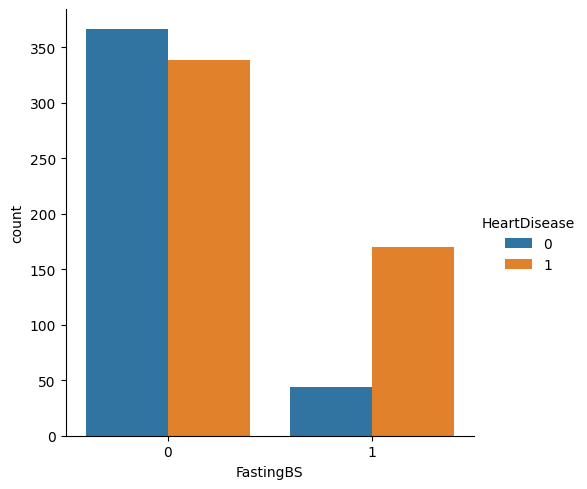

In [ ]:
# The Relation between FastingBS and HeartDisease
FastingBS = sns.catplot(x="FastingBS", hue="HeartDisease",data=data, kind = "count")
plt.show()

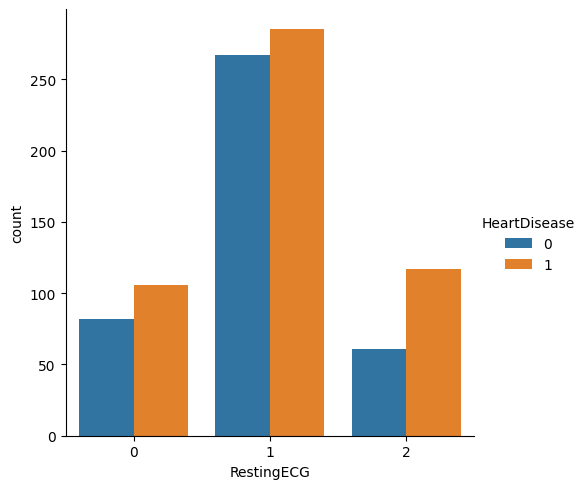

In [ ]:
# The Relation between RestingECG and HeartDisease
RestingECG = sns.catplot(x="RestingECG", hue="HeartDisease",data=data, kind = "count")
plt.show()

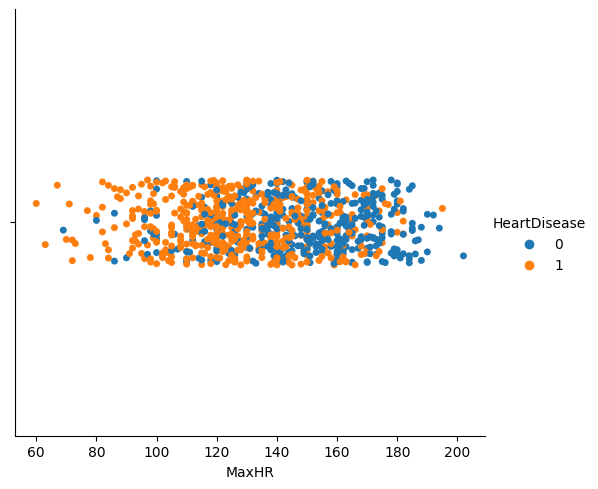

In [ ]:
# The Relation between MaxHR and HeartDisease
# we didn't do count here since the Max Heart Rate for the patients varies.
MaxHR = sns.catplot(x="MaxHR", hue="HeartDisease",data=data)
plt.show()

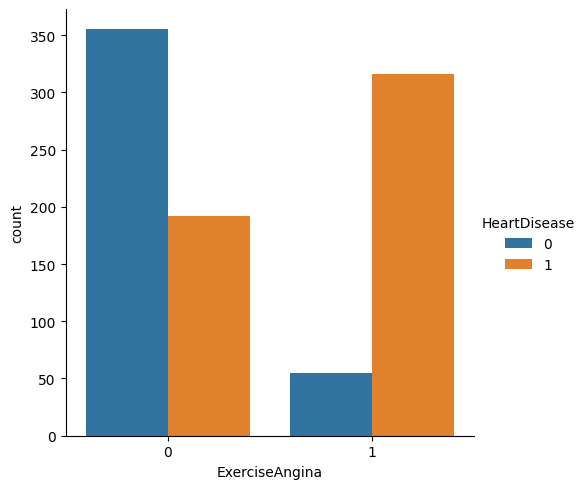

In [ ]:
# The Relation between ExerciseAngina and HeartDisease
ExerciseAngina = sns.catplot(x="ExerciseAngina", hue="HeartDisease",data=data, kind = "count")
plt.show()

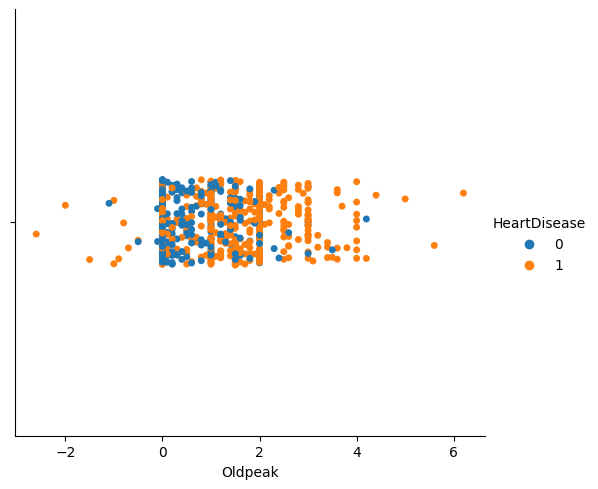

In [ ]:
# The Relation between Oldpeak and HeartDisease
# we didn't do count here since the Old peak for the patients varies.
Oldpeak = sns.catplot(x="Oldpeak", hue="HeartDisease",data=data)
plt.show()

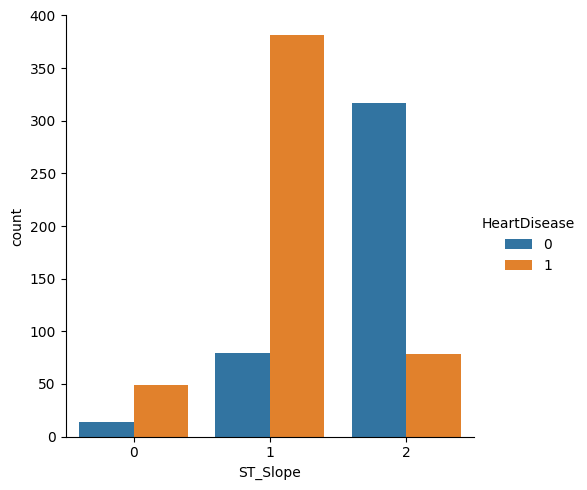

In [ ]:
# The Relation between ST_Slope and HeartDisease
ST_Slope = sns.catplot(x="ST_Slope", hue="HeartDisease",data=data, kind = "count")
plt.show()

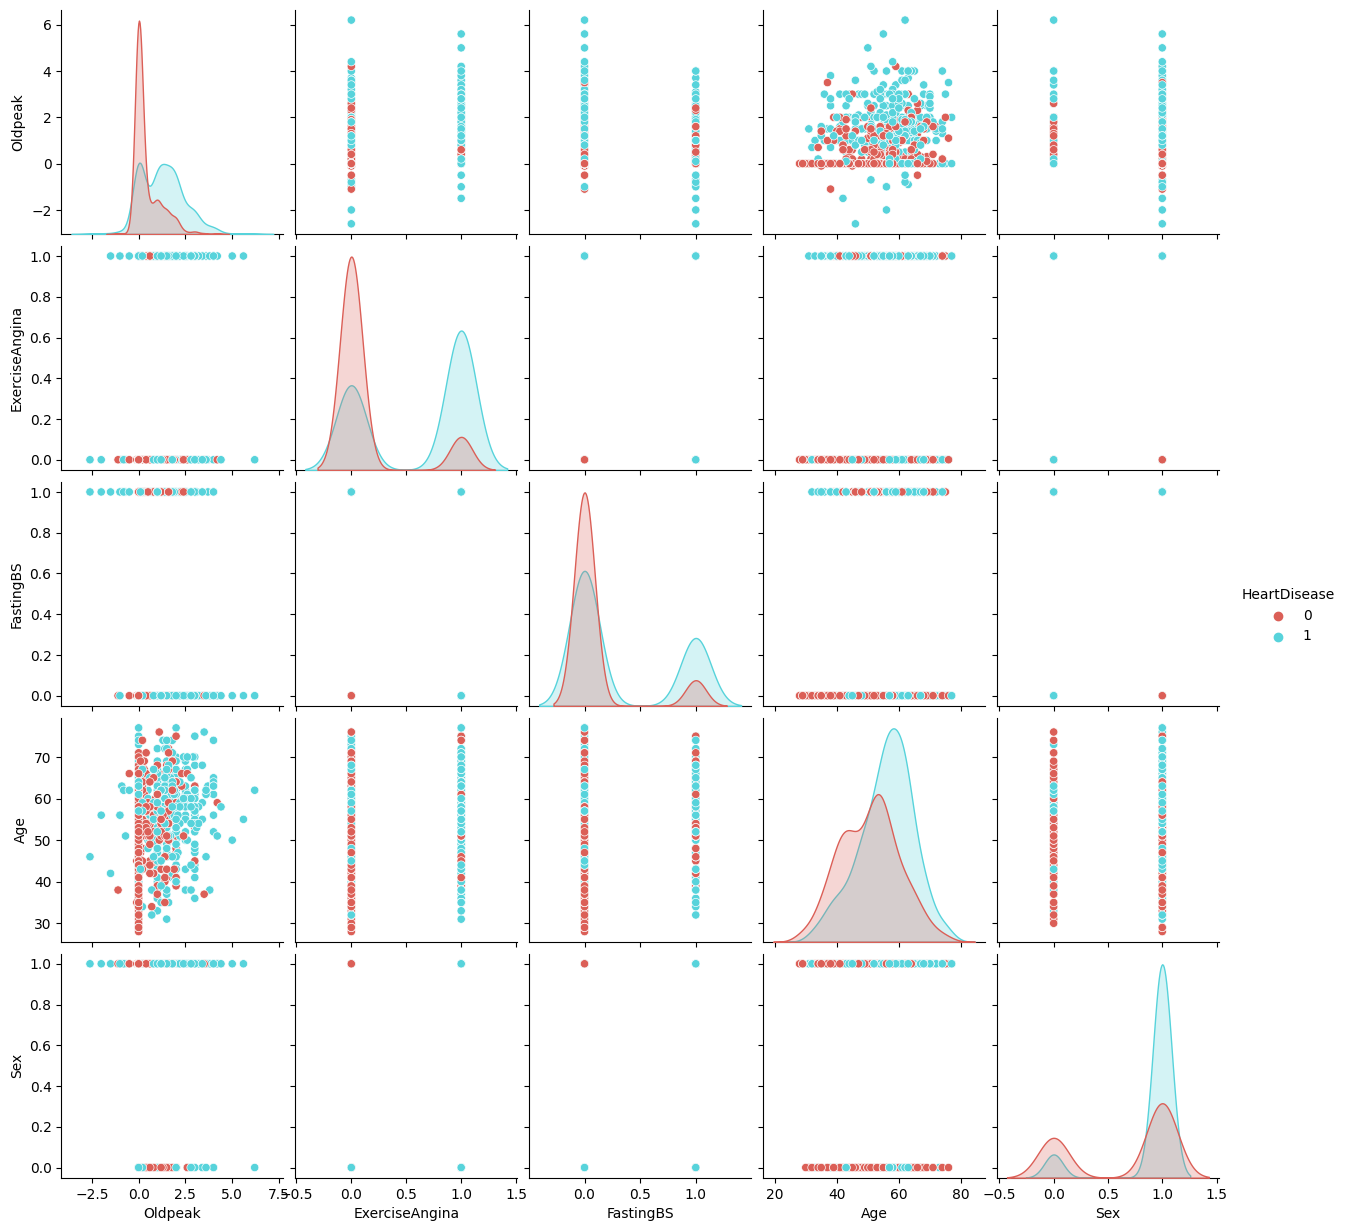

In [ ]:
# Relation Between The Best Features and Heart Disease
# plotting
sns.pairplot(data, vars=['Oldpeak' , 'ExerciseAngina', 'FastingBS', 'Age', 'Sex'], hue="HeartDisease" , palette='hls')
plt.show()



---



**Splitting Data and Scaling**

In [ ]:
# Split the data into features and target variable
X = data.drop('HeartDisease', axis=1)
y = data['HeartDisease']

In [ ]:
# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [ ]:
# Apply feature scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)



---



**First Model: Neural Network**

In [ ]:
# Create a neural network model
model = Sequential()
model.add(Dense(256, activation='relu', input_shape=(X_train_scaled.shape[1],)))
model.add(Dropout(0.5))
model.add(Dense(128, activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(64, activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(1, activation='sigmoid'))

In [ ]:
# Compile the model
optimizer = Adam(learning_rate=0.0005)
model.compile(loss='binary_crossentropy', optimizer=optimizer, metrics=['accuracy'])

In [ ]:
# Train the neural network model with increased epochs
model.fit(X_train_scaled, y_train, epochs=100, batch_size=32, verbose=1)

Epoch 1/100
21/21 [==============================] - 1s 3ms/step - loss: 0.6595 - accuracy: 0.6044
Epoch 2/100
21/21 [==============================] - 0s 3ms/step - loss: 0.5684 - accuracy: 0.7399
Epoch 3/100
21/21 [==============================] - 0s 3ms/step - loss: 0.4803 - accuracy: 0.7960
Epoch 4/100
21/21 [==============================] - 0s 4ms/step - loss: 0.4270 - accuracy: 0.8255
Epoch 5/100
21/21 [==============================] - 0s 3ms/step - loss: 0.4306 - accuracy: 0.8287
Epoch 6/100
21/21 [==============================] - 0s 4ms/step - loss: 0.4137 - accuracy: 0.8287
Epoch 7/100
21/21 [==============================] - 0s 3ms/step - loss: 0.4095 - accuracy: 0.8396
Epoch 8/100
21/21 [==============================] - 0s 4ms/step - loss: 0.3791 - accuracy: 0.8520
Epoch 9/100
21/21 [==============================] - 0s 4ms/step - loss: 0.3933 - accuracy: 0.8458
Epoch 10/100
21/21 [==============================] - 0s 3ms/step - loss: 0.3677 - accuracy: 0.8474
Epoch 11/

In [ ]:
# Evaluate the neural network model on the test set
y_pred_nn = model.predict(X_test_scaled)
y_pred_nn = (y_pred_nn > 0.5).astype(int)
accuracy_nn = accuracy_score(y_test, y_pred_nn)
print("Neural Network Accuracy:", accuracy_nn)
print(classification_report(y_test, y_pred_nn))

9/9 [==============================] - 0s 2ms/step
Neural Network Accuracy: 0.9130434782608695
              precision    recall  f1-score   support

           0       0.87      0.92      0.90       112
           1       0.94      0.91      0.93       164

    accuracy                           0.91       276
   macro avg       0.91      0.91      0.91       276
weighted avg       0.91      0.91      0.91       276





---



**Second Model: Random Forest Classifier**

In [ ]:
# Random Forest Classifier with hyperparameter tuning
rf_model = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)
accuracy_rf = accuracy_score(y_test, y_pred_rf)
print("Random Forest Accuracy:", accuracy_rf)
print(classification_report(y_test, y_pred_rf))

Random Forest Accuracy: 0.8913043478260869
              precision    recall  f1-score   support

           0       0.85      0.88      0.87       112
           1       0.92      0.90      0.91       164

    accuracy                           0.89       276
   macro avg       0.89      0.89      0.89       276
weighted avg       0.89      0.89      0.89       276



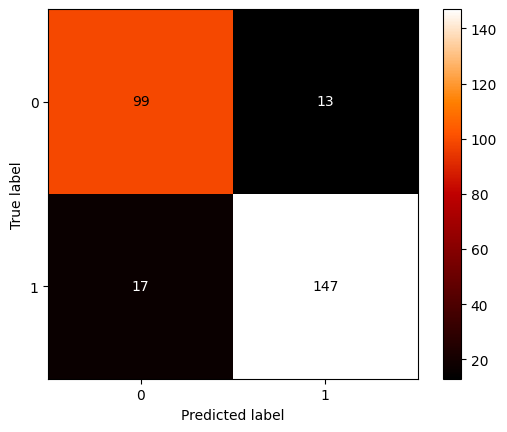

In [ ]:
cm_display = metrics.ConfusionMatrixDisplay.from_predictions( y_test, rf_model.predict(X_test), cmap ='gist_heat' )
plt.show()



---



**Third Model: Decision Tree:**

In [ ]:
from sklearn.tree import DecisionTreeClassifier
dTree = DecisionTreeClassifier()
dTree.fit(X_train,y_train)
dPred = dTree.predict(X_test)
print("Accuracy of Model::",accuracy_score(y_test,dPred))
print(classification_report(y_test, dPred))

Accuracy of Model:: 0.75
              precision    recall  f1-score   support

           0       0.66      0.79      0.72       112
           1       0.84      0.72      0.77       164

    accuracy                           0.75       276
   macro avg       0.75      0.76      0.75       276
weighted avg       0.76      0.75      0.75       276



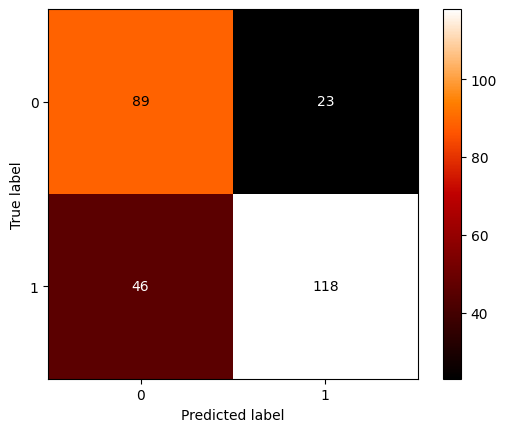

In [ ]:
cm_display = metrics.ConfusionMatrixDisplay.from_predictions( y_test, dTree.predict(X_test), cmap ='gist_heat' )
plt.show()



---



**Fourth Model: Support Vector Classification:**

In [ ]:
from sklearn.svm import SVC

svc = SVC().fit(X_train, y_train)
svcP = svc.predict(X_test)
print(accuracy_score(y_test, svcP))
print(classification_report(y_test, svcP))

0.7246376811594203
              precision    recall  f1-score   support

           0       0.65      0.71      0.68       112
           1       0.79      0.73      0.76       164

    accuracy                           0.72       276
   macro avg       0.72      0.72      0.72       276
weighted avg       0.73      0.72      0.73       276



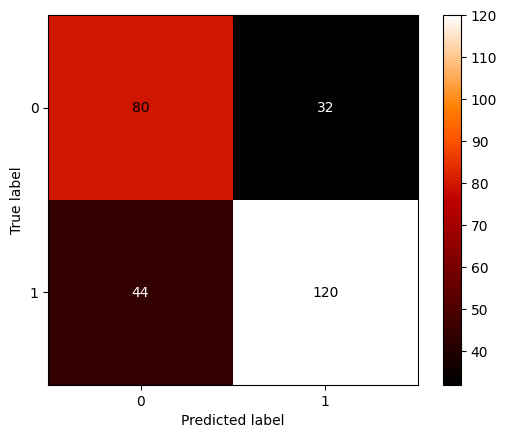

In [ ]:
cm_display = metrics.ConfusionMatrixDisplay.from_predictions( y_test, svcP, cmap ='gist_heat' )
plt.show()



---



**Fifth Model: K Neighbors Claasifier:**

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
KNN = KNeighborsClassifier().fit(X_train, y_train)
KNN_prediction = KNN.predict(X_test)
print(accuracy_score(y_test, KNN_prediction))
print(classification_report(y_test, KNN_prediction))

0.7137681159420289
              precision    recall  f1-score   support

           0       0.64      0.67      0.66       112
           1       0.77      0.74      0.76       164

    accuracy                           0.71       276
   macro avg       0.70      0.71      0.71       276
weighted avg       0.72      0.71      0.71       276



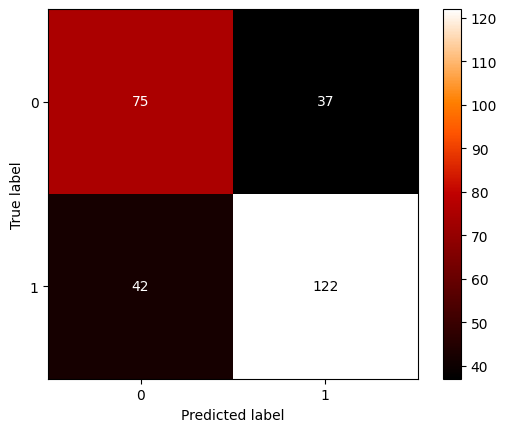

In [ ]:
cm_display = metrics.ConfusionMatrixDisplay.from_predictions( y_test, KNN_prediction, cmap ='gist_heat' )
plt.show()



---



**Sixth Model: Logisitic Regression Model:**

In [ ]:
from sklearn.linear_model import LogisticRegression

logistic_model = LogisticRegression(max_iter = 1000).fit(X_train, y_train)
logistic_prediction = logistic_model.predict(X_test)
print(accuracy_score(y_test, logistic_prediction))
print(classification_report(y_test, logistic_prediction))

0.8695652173913043
              precision    recall  f1-score   support

           0       0.81      0.89      0.85       112
           1       0.92      0.85      0.89       164

    accuracy                           0.87       276
   macro avg       0.86      0.87      0.87       276
weighted avg       0.87      0.87      0.87       276



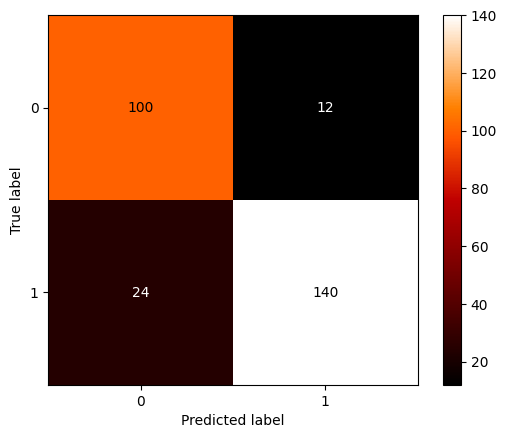

In [ ]:
cm_display = metrics.ConfusionMatrixDisplay.from_predictions( y_test, logistic_prediction, cmap ='gist_heat' )
plt.show()



---



**Seventh Model: GradientBoostingClassifier**

In [ ]:
from sklearn.ensemble import GradientBoostingClassifier
GradientBoosting = GradientBoostingClassifier().fit(X_train, y_train)
GradientBoosting_pre = GradientBoosting.predict(X_test)
print(accuracy_score(y_test, GradientBoosting_pre))
print(classification_report(y_test, GradientBoosting_pre))

0.8586956521739131
              precision    recall  f1-score   support

           0       0.79      0.88      0.84       112
           1       0.91      0.84      0.88       164

    accuracy                           0.86       276
   macro avg       0.85      0.86      0.86       276
weighted avg       0.86      0.86      0.86       276



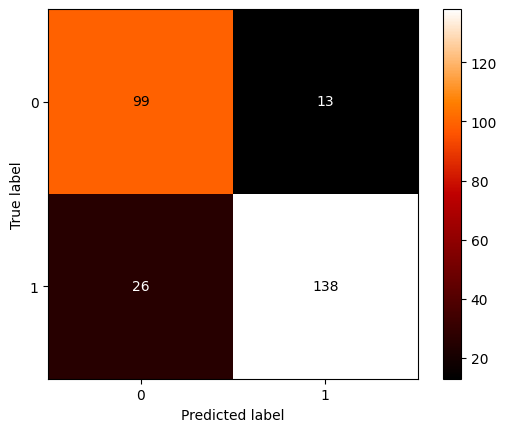

In [ ]:
cm_display = metrics.ConfusionMatrixDisplay.from_predictions( y_test, GradientBoosting_pre, cmap ='gist_heat' )
plt.show()



---



**Cross Validation**

In [ ]:
skFold = StratifiedKFold(n_splits=3)

 Decision Tree

In [ ]:
score = cross_val_score(dTree,X,y,cv = skFold)
print("Cross Validation Scores: {}".format(score))
print("Average Cross Validation score:{}".format(score.mean()))

Cross Validation Scores: [0.74836601 0.78104575 0.69607843]
Average Cross Validation score:0.7418300653594772


Random Forest

In [ ]:
score = cross_val_score(rf_model,X,y,cv = skFold)
print("Cross Validation Scores: {}".format(score))
print("Average Cross Validation score:{}".format(score.mean()))

Cross Validation Scores: [0.87581699 0.8627451  0.76143791]
Average Cross Validation score:0.8333333333333334


Logistic Classifier

In [ ]:
score = cross_val_score(logistic_model,X,y,cv = skFold)
print("Cross Validation Scores: {}".format(score))
print("Average Cross Validation score:{}".format(score.mean()))

Cross Validation Scores: [0.83986928 0.83660131 0.75816993]
Average Cross Validation score:0.8115468409586057


K Neighbors

In [ ]:
score = cross_val_score(KNN,X,y,cv = skFold)
print("Cross Validation Scores: {}".format(score))
print("Average Cross Validation score:{}".format(score.mean()))

Cross Validation Scores: [0.70261438 0.70588235 0.61764706]
Average Cross Validation score:0.6753812636165577


Support Vector Classifier

In [ ]:
score = cross_val_score(svc,X,y,cv = skFold)
print("Cross Validation Scores: {}".format(score))
print("Average Cross Validation score:{}".format(score.mean()))

Cross Validation Scores: [0.72222222 0.74836601 0.60130719]
Average Cross Validation score:0.6906318082788672


Gradient Boosting Classifier

In [ ]:
score = cross_val_score(GradientBoosting,X,y,cv = skFold)
print("Cross Validation Scores: {}".format(score))
print("Average Cross Validation score:{}".format(score.mean()))

Cross Validation Scores: [0.86928105 0.85294118 0.74183007]
Average Cross Validation score:0.8213507625272332




---



**Hyper Tuning The Best Model:**

In [ ]:
from sklearn.model_selection import GridSearchCV
from tensorflow.keras.wrappers.scikit_learn import KerasClassifier

In [ ]:
# Define a function to create the Neural Network model
def create_model():
    model = Sequential()
    model.add(Dense(256, activation='relu', input_shape=(X_train_scaled.shape[1],)))
    model.add(Dropout(0.5))
    model.add(Dense(128, activation='relu'))
    model.add(Dropout(0.5))
    model.add(Dense(64, activation='relu'))
    model.add(Dropout(0.5))
    model.add(Dense(1, activation='sigmoid'))
    optimizer = Adam(learning_rate=0.0005)
    model.compile(loss='binary_crossentropy', optimizer=optimizer, metrics=['accuracy'])
    return model

In [ ]:
# Create the KerasClassifier wrapper
keras_model = KerasClassifier(build_fn=create_model)

<ipython-input-59-8a10ed183424>:2: DeprecationWarning: KerasClassifier is deprecated, use Sci-Keras (https://github.com/adriangb/scikeras) instead. See https://www.adriangb.com/scikeras/stable/migration.html for help migrating.
  keras_model = KerasClassifier(build_fn=create_model)


In [ ]:
# Define the hyperparameter grid to search over
param_grid = {
    'batch_size': [32, 64, 128],
    'epochs': [50, 100, 150],
}

In [ ]:
# Perform grid search to find the best hyperparameters for the Neural Network model
grid_search = GridSearchCV(keras_model, param_grid, cv=3, scoring='accuracy')
grid_search.fit(X_train_scaled, y_train)

Streaming output truncated to the last 5000 lines.
Epoch 13/100
14/14 [==============================] - 0s 6ms/step - loss: 0.3666 - accuracy: 0.8668
Epoch 14/100
14/14 [==============================] - 0s 5ms/step - loss: 0.3715 - accuracy: 0.8505
Epoch 15/100
14/14 [==============================] - 0s 4ms/step - loss: 0.3560 - accuracy: 0.8551
Epoch 16/100
14/14 [==============================] - 0s 3ms/step - loss: 0.3546 - accuracy: 0.8621
Epoch 17/100
14/14 [==============================] - 0s 4ms/step - loss: 0.3323 - accuracy: 0.8762
Epoch 18/100
14/14 [==============================] - 0s 4ms/step - loss: 0.3246 - accuracy: 0.8738
Epoch 19/100
14/14 [==============================] - 0s 3ms/step - loss: 0.3584 - accuracy: 0.8598
Epoch 20/100
14/14 [==============================] - 0s 5ms/step - loss: 0.3596 - accuracy: 0.8692
Epoch 21/100
14/14 [==============================] - 0s 4ms/step - loss: 0.3326 - accuracy: 0.8668
Epoch 22/100
14/14 [=============================

GridSearchCV(cv=3,
             estimator=<keras.wrappers.scikit_learn.KerasClassifier object at 0x7fe2f96c0850>,
             param_grid={'batch_size': [32, 64, 128], 'epochs': [50, 100, 150]},
             scoring='accuracy')

In [ ]:
# Get the best hyperparameters and best model for the Neural Network
best_params = grid_search.best_params_
best_model = grid_search.best_estimator_

In [ ]:
print("Best Hyperparameters:", best_params)

Best Hyperparameters: {'batch_size': 32, 'epochs': 50}




---



**Testing New Rows: New Patients**

In [ ]:
new_person_data = {
    'Age': [30],
    'Sex': ['M'],
    'ChestPainType': ['ATA'],
    'RestingBP': [140],
    'Cholesterol': [150],
    'FastingBS': [0],
    'RestingECG': ['Normal'],
    'MaxHR': [172],
    'ExerciseAngina': ['N'],
    'Oldpeak': [0],
    'ST_Slope': ['Up']
}

new_person_df = pd.DataFrame(new_person_data)

In [ ]:
new_person_encoded = pd.get_dummies(new_person_df, columns=['Sex', 'ChestPainType', 'RestingECG', 'ExerciseAngina', 'ST_Slope'])

In [ ]:
# Reorder the columns to match the training data
new_person_encoded = new_person_encoded.reindex(columns=X.columns, fill_value=0)

In [ ]:
# Apply feature scaling
new_person_scaled = scaler.transform(new_person_encoded)

In [ ]:
# Make prediction using the trained neural network model
prediction = model.predict(new_person_scaled)
probabilities = prediction.flatten()

1/1 [==============================] - 0s 36ms/step


In [ ]:
# Convert the probabilities to binary predictions (0 or 1)
predictions_binary = (probabilities > 0.5).astype(int)

In [ ]:
# Get the probability of the positive class (heart disease)
probability = probabilities[0] if predictions_binary[0] == 1 else 1 - probabilities[0]

In [ ]:
# Print the predicted label and probability
predicted_label = predictions_binary[0]
print("Predicted Label:", predicted_label)
print("Predicted Probability:", probability)

Predicted Label: 1
Predicted Probability: 0.9555106
